# Model Analysis — every trained extrapolator NN, and what we actually know

**Scope**: all training runs in `TrackExtrapolation/experiments/gen_3/trained_models/` (gen-3 → gen-4 → wave-2 → E-series → physics-loss study) plus today's vertex-fit retrains in `experiments/vertexfit/trained_models/`. Everything below is read from the stored `history.json` / `config.json` / results JSONs of the runs themselves — no numbers are re-derived.

**Reading guide — the corpora behind the runs** (they are *not* comparable across generations):
- **gen-3** (pre 2026-06-11): trained on the **κ-bug corpus** (κ = 10⁻⁶, ~1000× too-weak field). The locked Allen candidate `candidate/pinn_v2_ALLEN_v1` (tagged 2026-05-20) is from this era: its 11.7 µm median and A4 Jacobian pass are real *on that data*, but the data was the wrong physics. Kept for the record.
- **gen-4 / wave-2 / scans / E-series / physloss** (post-fix): physical κ = 10⁻³, v8r1 field, UT→T-weighted corpora. The judged metric is `utt_median_dx_um` — median |Δx| on the UT→T regime (z₀∈[2300,3000] → z₁∈[7600,9500] mm).
- **vertex-fit** (2026-07-03): the new 9.97 M corpus (legs A/B/C/D); metric = per-leg tier-1 vs the PLAN bars.

**The four standing questions this notebook answers**
1. Which NNs are *complete*, and how good are they?
2. Does the PINN physics (collocation) loss help or hurt? *(three controlled ablations)*
3. How do hidden dimensions / depth affect accuracy?
4. How do they affect **cost** (FLOPs + measured CPU latency)?

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

GEN3 = Path("/data/bfys/gscriven/TrackExtrapolation/experiments/gen_3/trained_models")
VF   = Path("/data/bfys/gscriven/TrackExtrapolation/experiments/vertexfit")
REPO = Path("/data/bfys/gscriven/track-extrapolation-pinn")

C1, C2, C3, C4 = "#2a78d6", "#1baf7a", "#eda100", "#008300"   # categorical slots 1-4
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "figure.dpi": 110,
    "legend.frameon": False,
})

def scan(base):
    rows = []
    for d in sorted(base.iterdir()):
        h, cf = d / "history.json", d / "config.json"
        if not cf.exists(): continue
        cfg = json.load(open(cf))
        rec = {"run": d.name, "dims": str(cfg.get("hidden_dims")),
               "lambda_pde": cfg.get("lambda_pde"), "n_unroll": cfg.get("n_unroll", 1),
               "kick": bool(cfg.get("kick_scaled_head", False)),
               "loss": cfg.get("loss"), "utt_med_um": np.nan,
               "bulk_med_mm": np.nan, "best_ep": None, "wall_h": np.nan}
        if h.exists():
            j = json.load(open(h))
            t = j.get("test_final", {})
            rec.update(utt_med_um=t.get("utt_median_dx_um", np.nan),
                       bulk_med_mm=t.get("median_dx_mm", np.nan),
                       best_ep=j.get("best_epoch"),
                       wall_h=j.get("training_time_s", np.nan) / 3600)
        rows.append(rec)
    return pd.DataFrame(rows)

inv = scan(GEN3)
print(f"{len(inv)} runs in gen_3/trained_models (full inventory):")
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 80)
inv.round(2)

60 runs in gen_3/trained_models (full inventory):


,run,dims,lambda_pde,n_unroll,kick,loss,utt_med_um,bulk_med_mm,best_ep,wall_h
0,e1_unroll16,"[96, 96]",0.00,16,True,residual_rel,1255.74,0.23,243.0,5.28
1,e1_unroll2,"[96, 96]",0.00,2,True,residual_rel,1496.40,0.46,120.0,1.34
2,e1_unroll32,"[96, 96]",0.00,32,True,residual_rel,1257.93,0.21,199.0,3.07
3,e1_unroll4,"[96, 96]",0.00,4,True,residual_rel,1488.53,0.37,114.0,1.33
4,e1_unroll8,"[96, 96]",0.00,8,True,residual_rel,1394.78,0.31,117.0,1.14
5,e1_unroll8_long,"[96, 96]",0.00,8,True,residual_rel,1293.82,0.28,214.0,3.86
6,e2_order2_unroll16,"[96, 96]",0.00,16,True,residual_rel,1257.57,0.22,236.0,6.71
7,e2_order2_unroll8,"[96, 96]",0.00,8,True,residual_rel,1325.01,0.25,235.0,4.42
8,e5_hybrid_n2,"[64, 64]",0.00,1,True,residual_rel,NaN,NaN,NaN,NaN
9,e5_hybrid_n4,"[64, 64]",0.00,1,True,residual_rel,NaN,NaN,NaN,NaN


## 1. The completed / decision-carrying models

| Model | Corpus | Result | Status |
|---|---|---|---|
| `candidate/pinn_v2_ALLEN_v1` (h96, 10,372 par, 40.5 KB) | gen-3 (**κ-bug**) | 11.7 µm median, p95 0.45 mm on its own test; **A4 Jacobian gate PASS ~100× margin** | locked + exported to Allen (`PINN_V2_UTT.cuh`); MR !2497 built, **never merged**; superseded by the κ discovery |
| wave-2 family h32…h384 (endpoint, residual-Huber) | gen-4 physical | UT→T median **~3.1–3.8 mm** (table below) | complete — established the ~3 mm single-shot floor; endpoint route **closed** |
| E-series unroll (h96, kick, N sub-steps) | gen-4 physical | UT→T median **~1.25 mm** at N=16 (saturates) | complete — the only lever that ever beat the floor, still 100× off `extrapUTT` |
| physloss study (6 GPU runs) | gen-4 physical | λ_pde ablation **null** (below) | complete — awaiting George's call on the physics-loss PLAN |
| vertex-fit `vf_resid_h64/h96` (2026-07-03) | vertex-fit 9.97 M | leg-A median 269/273 µm (bar 100 µm), C/D regression | **current line** — P3 lever choice pending |

Context that frames all endpoint numbers: on the same UT→T population the incumbent **`extrapUTT` polynomial sits at 10.9 µm** median and straight-line at 225 mm (`results/wave2/wave2_three_arm.json`) — the NN family landed 300× short of the chart, which is why the endpoint-replacement line was closed and the effort retargeted at the vertex-fit loop.

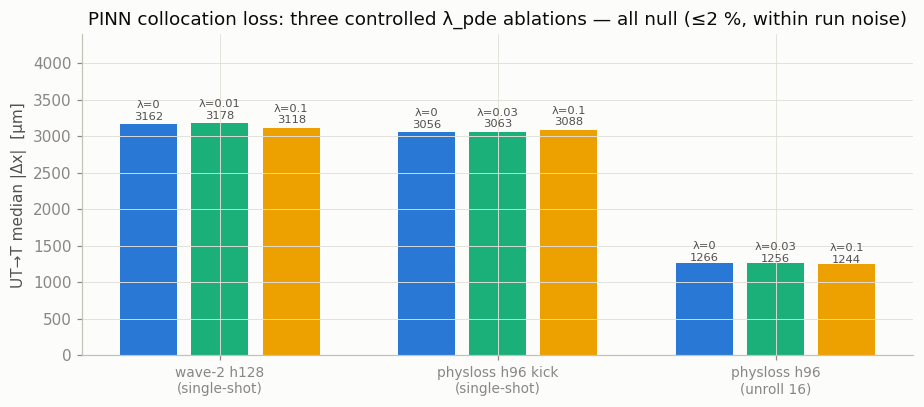

wave-2 h128 (single-shot)         spread 1.9%   wall 0.7->1.7 h
physloss h96 kick (single-shot)   spread 1.1%   wall 7.6->10.0 h
physloss h96 (unroll 16)          spread 1.8%   wall 7.9->12.6 h


In [2]:
# --- Q2: does the PINN collocation loss help? Three controlled ablations ---
abl = {
    "wave-2 h128\n(single-shot)": {"0": "wave2_resid_h128", "0.01": "wave2_lam0p01_h128", "0.1": "wave2_lam0p1_h128"},
    "physloss h96 kick\n(single-shot)": {"0": "physloss_kick_lpde0", "0.03": "physloss_kick_lpde0p03", "0.1": "physloss_kick_lpde0p1"},
    "physloss h96\n(unroll 16)": {"0": "physloss_unroll16_lpde0", "0.03": "physloss_unroll16_lpde0p03", "0.1": "physloss_unroll16_lpde0p1"},
}
g = inv.set_index("run")
fig, ax = plt.subplots(figsize=(8.5, 3.8))
lam_colors = {"0": C1, "0.01": C2, "0.03": C2, "0.1": C3}
xpos, ticks = [], []
x = 0.0
for grp, runs in abl.items():
    for lam, run in runs.items():
        v = g.loc[run, "utt_med_um"]; w = g.loc[run, "wall_h"]
        ax.bar(x, v, width=0.8, color=lam_colors[lam])
        ax.text(x, v * 1.02, f"λ={lam}\n{v:.0f}", ha="center", fontsize=7.5, color=INK2)
        x += 1
    ticks.append((x - 2, grp)); x += 0.9
ax.set_xticks([t for t, _ in ticks]); ax.set_xticklabels([n for _, n in ticks], fontsize=9)
ax.set_ylabel("UT→T median |Δx|  [µm]")
ax.set_title("PINN collocation loss: three controlled λ_pde ablations — all null (≤2 %, within run noise)")
ax.set_ylim(0, 4400)
plt.tight_layout(); plt.show()
for grp, runs in abl.items():
    vals = [g.loc[r, 'utt_med_um'] for r in runs.values()]
    walls = [g.loc[r, 'wall_h'] for r in runs.values()]
    print(f"{grp.replace(chr(10),' '):32s}  spread {100*(max(vals)-min(vals))/min(vals):.1f}%   wall {min(walls):.1f}->{max(walls):.1f} h")

**Answer 2 — the physics loss is a null result, three times over.** At single-shot h128, at single-shot h96-kick, and at unroll-16, sweeping λ_pde over 0 / 0.01–0.03 / 0.1 moves the UT→T median by ≤ 2 % — inside run-to-run noise — while the collocation term adds up to ~30 % wall time (7.6 → 10 h on the kick arm). The physics that *did* matter was put into the **architecture** instead: the IC-preserving envelope, the κ·dz kick scaling, and the multi-step unroll (below). This is the evidence base for the open "physics-loss PLAN fate" decision.

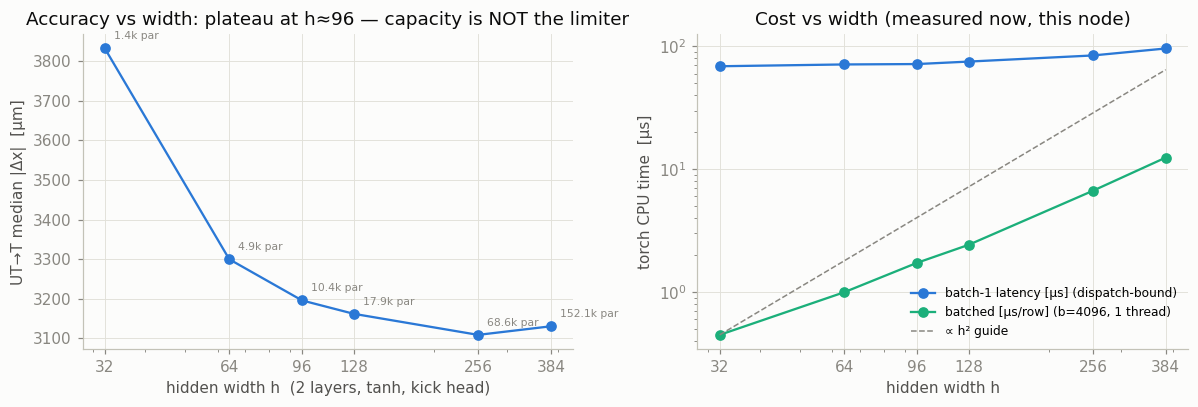

,h,params,UT→T med [µm],batch-1 [µs],batched [µs/row],MAC/call
0,32,1412,3832.0,68.8,0.448,1344
1,64,4868,3300.0,71.2,0.995,4736
2,96,10372,3196.0,71.7,1.727,10176
3,128,17924,3162.0,75.1,2.419,17664
4,256,68612,3109.0,84.2,6.672,68096
5,384,152068,3130.0,96.0,12.422,151296


In [3]:
# --- Q3+Q4: hidden dims -> accuracy (stored) and cost (measured now) ---
import torch
torch.set_num_threads(1)
hs = [32, 64, 96, 128, 256, 384]
acc = [g.loc[f"wave2_resid_h{h}", "utt_med_um"] for h in hs]
par, lat1, latb = [], [], []
for h in hs:
    net = torch.nn.Sequential(torch.nn.Linear(6, h), torch.nn.Tanh(),
                              torch.nn.Linear(h, h), torch.nn.Tanh(),
                              torch.nn.Linear(h, 4)).eval()
    par.append(sum(p.numel() for p in net.parameters()))
    with torch.no_grad():
        x1, xb = torch.randn(1, 6), torch.randn(4096, 6)
        for _ in range(200): net(x1)
        t = time.perf_counter_ns()
        for _ in range(600): net(x1)
        lat1.append((time.perf_counter_ns() - t) / 600 / 1e3)      # µs
        for _ in range(10): net(xb)
        t = time.perf_counter_ns()
        for _ in range(30): net(xb)
        latb.append((time.perf_counter_ns() - t) / 30 / 4096 / 1e3) # µs/row

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(hs, acc, "-o", color=C1, ms=6)
for h, a, p in zip(hs, acc, par):
    axes[0].annotate(f"{p/1e3:.1f}k par", (h, a), textcoords="offset points",
                     xytext=(6, 6), fontsize=7, color=MUTED)
axes[0].set_xscale("log"); axes[0].set_xticks(hs); axes[0].set_xticklabels(hs)
axes[0].set_xlabel("hidden width h  (2 layers, tanh, kick head)")
axes[0].set_ylabel("UT→T median |Δx|  [µm]")
axes[0].set_title("Accuracy vs width: plateau at h≈96 — capacity is NOT the limiter")
axes[1].plot(hs, lat1, "-o", color=C1, ms=6, label="batch-1 latency [µs] (dispatch-bound)")
axes[1].plot(hs, latb, "-o", color=C2, ms=6, label="batched [µs/row] (b=4096, 1 thread)")
axes[1].plot(hs, [latb[0] * (h / hs[0]) ** 2 for h in hs], ls="--", lw=1,
             color=MUTED, label="∝ h² guide")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xticks(hs); axes[1].set_xticklabels(hs)
axes[1].set_xlabel("hidden width h"); axes[1].set_ylabel("torch CPU time  [µs]")
axes[1].set_title("Cost vs width (measured now, this node)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame({"h": hs, "params": par, "UT→T med [µm]": np.round(acc, 0),
              "batch-1 [µs]": np.round(lat1, 1), "batched [µs/row]": np.round(latb, 3),
              "MAC/call": [6*h + h*h + 4*h for h in hs]})

**Answer 3+4 — width buys nothing past h≈96; cost grows ~h².** h32→h96 improves the UT→T median 17 % (3832→3196 µm); h96→h384 (14× the parameters) improves it another 2 % — flat. Depth/activation (scanA, gen-4): going 2→3 layers at h64 helps ~8 % (tanh 3300→3027 µm), `sin` is unstable at depth 3 (early-stopped, 4005 µm); tanh/gelu equivalent. Meanwhile batched cost grows roughly quadratically with width and batch-1 latency is flat — pure torch dispatch overhead (~60–70 µs) regardless of size. Deployment cost argument therefore favours the **smallest network on the accuracy plateau: h64–h96**.

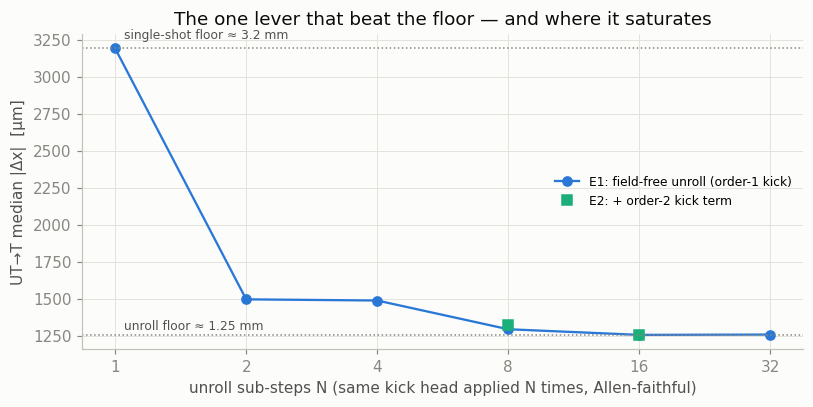

In [4]:
# --- what actually moved accuracy: the E1 multi-step unroll ladder ---
unroll = {1: "wave2_resid_h96", 2: "e1_unroll2", 4: "e1_unroll4",
          8: "e1_unroll8_long", 16: "e1_unroll16", 32: "e1_unroll32"}
e2 = {8: "e2_order2_unroll8", 16: "e2_order2_unroll16"}
ns  = sorted(unroll)
ys  = [g.loc[unroll[n], "utt_med_um"] for n in ns]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(ns, ys, "-o", color=C1, ms=6, label="E1: field-free unroll (order-1 kick)")
ax.plot(sorted(e2), [g.loc[e2[n], "utt_med_um"] for n in sorted(e2)], "s",
        color=C2, ms=7, label="E2: + order-2 kick term")
ax.axhline(3196, color=MUTED, ls=":", lw=1); ax.text(1.05, 3260, "single-shot floor ≈ 3.2 mm", fontsize=8, color=INK2)
ax.axhline(1256, color=MUTED, ls=":", lw=1); ax.text(1.05, 1290, "unroll floor ≈ 1.25 mm", fontsize=8, color=INK2)
ax.set_xscale("log", base=2); ax.set_xticks(ns); ax.set_xticklabels(ns)
ax.set_xlabel("unroll sub-steps N (same kick head applied N times, Allen-faithful)")
ax.set_ylabel("UT→T median |Δx|  [µm]")
ax.set_title("The one lever that beat the floor — and where it saturates")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

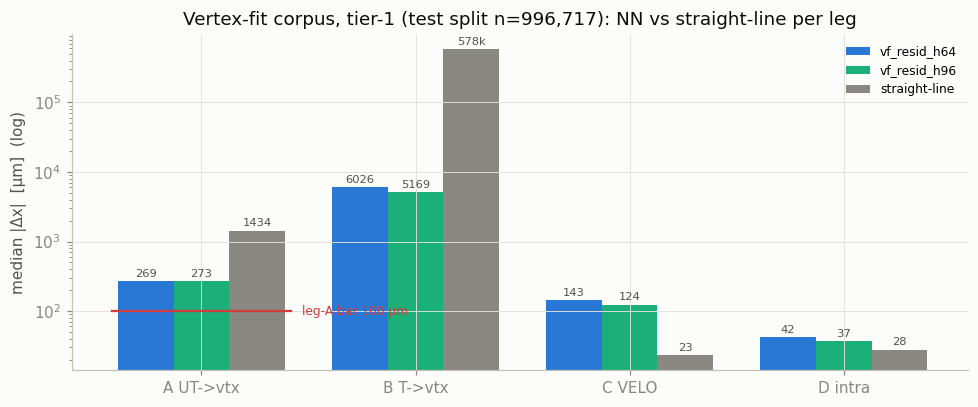

stop-rule (leg-A med >> 1 mm): False | leg-A bars: {'med_dx_um': False, 'p95_dx_um': False, 'med_slope_urad': False}


In [5]:
# --- current line: vertex-fit retrains (2026-07-03) per leg vs straight-line ---
vf = json.load(open(VF / "results" / "VF_tier1_20260703.json"))
legs = ["A UT->vtx", "B T->vtx", "C VELO", "D intra"]
fig, ax = plt.subplots(figsize=(9, 3.8))
w, xs = 0.26, np.arange(4)
for off, (name, color) in zip((-w, 0, w),
        [("vf_resid_h64", C1), ("vf_resid_h96", C2), ("straight-line", MUTED)]):
    if name == "straight-line":
        vals = [vf[0]["legs"][l]["straight"]["med_dx_um"] for l in legs]
    else:
        r = next(r for r in vf if r["experiment"] == name)
        vals = [r["legs"][l]["nn"]["med_dx_um"] for l in legs]
    b = ax.bar(xs + off, vals, width=w, color=color, label=name)
    for xi, v in zip(xs + off, vals):
        ax.text(xi, v * 1.15, f"{v:.0f}" if v < 1e4 else f"{v/1e3:.0f}k",
                ha="center", fontsize=7.5, color=INK2)
ax.plot([-w*1.6, w*1.6], [100, 100], color="#d03b3b", lw=1.5)
ax.text(w*1.8, 100, "leg-A bar 100 µm", fontsize=8, color="#d03b3b", va="center")
ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels(legs)
ax.set_ylabel("median |Δx|  [µm]  (log)")
ax.set_title("Vertex-fit corpus, tier-1 (test split n=996,717): NN vs straight-line per leg")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()
print("stop-rule (leg-A med >> 1 mm):", vf[0]["stop_rule_triggered"],
      "| leg-A bars:", {k: v["pass"] for k, v in vf[0]["bars_leg_A"].items()})

## Summary — what we know, run-verified

1. **Complete NNs**: the locked (pre-κ-fix, unmerged) Allen candidate; the wave-2 endpoint family (route closed at the ~3.1 mm UT→T floor vs `extrapUTT` at 10.9 µm); the E-series unroll models (floor → 1.25 mm, saturated); the physloss sextet; today's two vertex-fit retrains.
2. **PINN collocation loss: null**, in three controlled ablations (≤2 % effect, up to +30 % wall time). The productive "physics" has been architectural: envelope IC, κ·dz kick scaling, multi-step unroll.
3. **Width plateaus at h≈96** (h384 = 14× params for 2 %); depth 3 helps ~8 %; `sin` unstable at depth 3. Cost grows ~h² batched; batch-1 torch is dispatch-bound (~60–70 µs) at every size.
4. **Unroll is the only accuracy lever found** on the full crossing (3.2 → 1.25 mm at N=16, E2 second-order term adds nothing).
5. **Vertex-fit line (current)**: leg-A 269 µm (bar 100 µm), 5.3× better than straight-line; legs C/D regress vs straight-line — the P3 decision (correction gating / J-supervision / slope-head rescale) is open.

*Provenance: every number is read from the runs' own `history.json`/`config.json`, `results/wave2/*.json`, `results/VF_tier1_20260703.json`, `candidate/pinn_v2_ALLEN_v1/TAG_INFO.json`; latency measured live on this node (single-thread torch 2.9). Built 2026-07-03.*